# Exploratory Data Analysis and Advanced Weather Analysis

## Objective

This notebook explores global weather patterns using the processed weather dataset. The analysis focuses on identifying trends, correlations, environmental patterns, and geographical variations across different regions.

The notebook includes:
- Exploratory Data Analysis (EDA)
- Temperature and precipitation analysis
- Correlation analysis
- Climate and environmental analysis
- Anomaly detection
- Spatial and geographical analysis

The insights obtained from this analysis will support the forecasting models developed later in the project.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

sns.set_style("whitegrid")

# Load Processed Dataset

The cleaned and preprocessed dataset is loaded for exploratory and advanced analysis.

In [3]:
DATA_PATH = Path("../data/processed/weather_cleaned.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (139948, 51)


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,wind_mph,wind_kph,wind_degree,wind_direction,pressure_mb,pressure_in,precip_mm,precip_in,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,visibility_miles,uv_index,gust_mph,gust_kph,air_quality_carbon_monoxide,air_quality_ozone,air_quality_nitrogen_dioxide,air_quality_sulphur_dioxide,air_quality_pm2.5,air_quality_pm10,air_quality_us_epa_index,air_quality_gb_defra_index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination,year,month,day,hour,day_of_year,weekday,is_weekend,is_day,season,temp_difference
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15:00,26.6,79.8,Partly Cloudy,8.3,13.3,338,NNW,1012.0,29.89,0.0,0.00,24,30,25.3,77.5,10.0,6.0,7.0,9.5,15.3,277.0,103.0,1.1,0.2,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55,2024,5,16,13,137,Thursday,0,1,Spring,-1.3
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45:00,19.0,66.2,Partly cloudy,6.9,11.2,320,NW,1012.0,29.88,0.1,0.00,94,75,19.0,66.2,10.0,6.0,5.0,11.4,18.4,193.6,97.3,0.9,0.1,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55,2024,5,16,10,137,Thursday,0,1,Spring,0.0
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45:00,23.0,73.4,Sunny,9.4,15.1,280,W,1011.0,29.85,0.0,0.00,29,0,24.6,76.4,10.0,6.0,5.0,13.9,22.3,540.7,12.2,65.1,13.4,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55,2024,5,16,9,137,Thursday,0,1,Spring,1.6
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45:00,6.3,43.3,Light drizzle,7.4,11.9,215,SW,1007.0,29.75,0.3,0.01,61,100,3.8,38.9,2.0,1.0,2.0,8.5,13.7,170.2,64.4,1.6,0.2,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55,2024,5,16,10,137,Thursday,0,1,Spring,-2.5
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45:00,26.0,78.8,Partly cloudy,8.1,13.0,150,SSE,1011.0,29.85,0.0,0.00,89,50,28.7,83.6,10.0,6.0,8.0,12.5,20.2,2964.0,19.0,72.7,31.5,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55,2024,5,16,9,137,Thursday,0,1,Spring,2.7


# Dataset Overview

This section provides a high-level understanding of the dataset structure, feature types, and overall data composition.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 139948 entries, 0 to 139947
Data columns (total 51 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       139948 non-null  str    
 1   location_name                 139948 non-null  str    
 2   latitude                      139948 non-null  float64
 3   longitude                     139948 non-null  float64
 4   timezone                      139948 non-null  str    
 5   last_updated_epoch            139948 non-null  int64  
 6   last_updated                  139948 non-null  str    
 7   temperature_celsius           139948 non-null  float64
 8   temperature_fahrenheit        139948 non-null  float64
 9   condition_text                139948 non-null  str    
 10  wind_mph                      139948 non-null  float64
 11  wind_kph                      139948 non-null  float64
 12  wind_degree                   139948 non-null  int64  


In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country,139948,211,Bulgaria,1656,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location_name,139948,257,Kabul,720,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,139948.0,NaN,NaN,NaN,19.21493,24.413648,-41.3,4.0503,17.25,40.4,64.15
longitude,139948.0,NaN,NaN,NaN,21.944697,65.784957,-175.2,-6.8361,23.2361,49.8822,179.22
timezone,139948,199,Asia/Bangkok,2568,NaN,NaN,NaN,NaN,NaN,NaN,NaN
last_updated_epoch,139948.0,NaN,NaN,NaN,1746994231.944722,17976485.877554,1715849100.0,1731488400.0,1747040400.0,1762503300.0,1778135400.0
last_updated,139948,23224,2025-12-26 08:15:00,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN
temperature_celsius,139948.0,NaN,NaN,NaN,21.244525,9.660899,-29.8,15.6,23.8,28.0,79.3
temperature_fahrenheit,139948.0,NaN,NaN,NaN,70.241942,17.389484,-21.6,60.1,74.8,82.4,174.7
condition_text,139948,49,Sunny,40281,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Feature Categories

The dataset contains multiple categories of features related to weather, geography, air quality, and time.

### Geographical Features
- Country
- Location name
- Latitude
- Longitude
- Timezone

### Weather Features
- Temperature
- Humidity
- Wind speed
- Pressure
- Precipitation
- Cloud cover
- Visibility
- UV index

### Air Quality Features
- Carbon monoxide
- Ozone
- Nitrogen dioxide
- Sulphur dioxide
- PM2.5
- PM10
- EPA air quality indices

### Time Features
- Year
- Month
- Day
- Hour
- Season
- Weekday

# Univariate Analysis

Univariate analysis focuses on understanding the distribution and behavior of individual variables within the dataset.

This section examines important weather and environmental variables such as:
- Temperature
- Humidity
- Precipitation
- Visibility
- Air quality indicators

The goal is to identify:
- Distribution patterns
- Seasonal behavior
- Skewness
- Extreme observations
- Environmental variability

## Temperature Distribution

Temperature is one of the most important weather indicators. Understanding its distribution helps identify common climatic conditions and extreme weather observations.

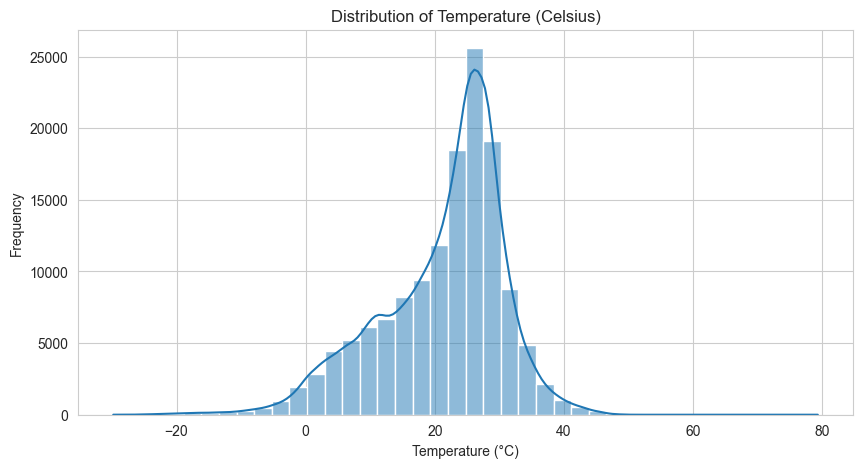

<Figure size 640x480 with 0 Axes>

In [6]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["temperature_celsius"],
    bins=40,
    kde=True
)

plt.title("Distribution of Temperature (Celsius)")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")

plt.show()

plt.savefig("../visuals/monthly_temperature_trend.png", bbox_inches="tight")

### Observations

- The temperature distribution is approximately bell-shaped with a slight left skew.
- Most observations fall between 15°C and 30°C, indicating that moderate-to-warm temperatures dominate the dataset.
- The highest concentration of values appears around 24°C–27°C.
- Extremely low and extremely high temperatures occur less frequently but are still present, reflecting diverse global climatic conditions.
- The distribution confirms that the dataset captures weather observations from a wide range of geographical regions and climates.

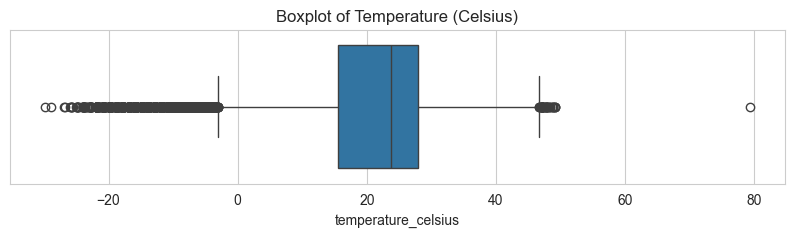

In [7]:
plt.figure(figsize=(10, 2))

sns.boxplot(
    x=df["temperature_celsius"]
)

plt.title("Boxplot of Temperature (Celsius)")

plt.show()

### Boxplot Observations

- The median temperature is centered around the mid-20s °C.
- Most observations fall within a relatively moderate temperature range.
- Multiple outliers are visible on both the lower and upper ends of the distribution.
- Low-temperature outliers likely represent colder climatic regions, while high-temperature outliers correspond to extreme heat conditions.
- A few extremely high temperature values appear unusually distant from the main distribution and may represent rare environmental events or potential data anomalies.
- The boxplot confirms the presence of substantial climatic variability across global locations.

## Humidity Distribution

Humidity levels influence perceived temperature, precipitation, and overall weather comfort. Analyzing humidity distribution helps understand atmospheric moisture conditions globally.

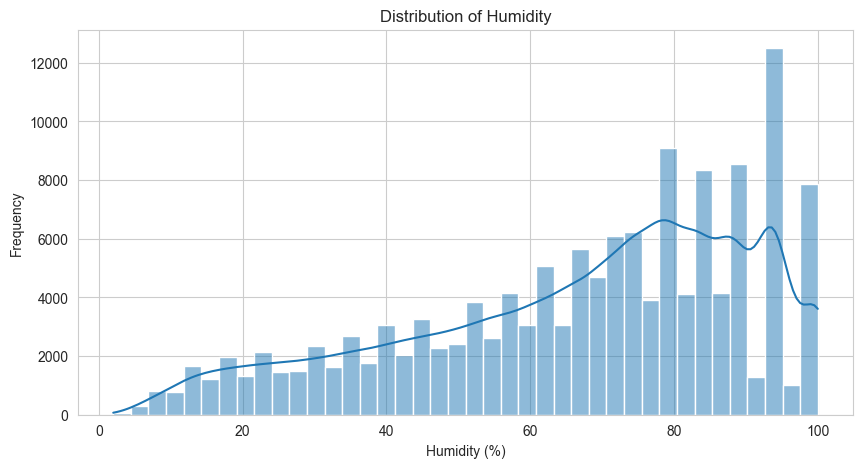

In [8]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["humidity"],
    bins=40,
    kde=True
)

plt.title("Distribution of Humidity")
plt.xlabel("Humidity (%)")
plt.ylabel("Frequency")

plt.show()

### Observations

- The humidity distribution is skewed toward higher values.
- Most humidity observations fall between 60% and 95%.
- High humidity conditions appear significantly more common than dry conditions.
- The dataset contains a strong concentration of moist atmospheric environments, likely influenced by tropical, coastal, and rainy regions.
- Extremely low humidity levels occur less frequently, indicating fewer observations from highly arid climates.
- The distribution highlights substantial global variability in atmospheric moisture conditions.`

## Precipitation Distribution

Precipitation analysis helps identify rainfall intensity patterns and extreme weather conditions across different regions.

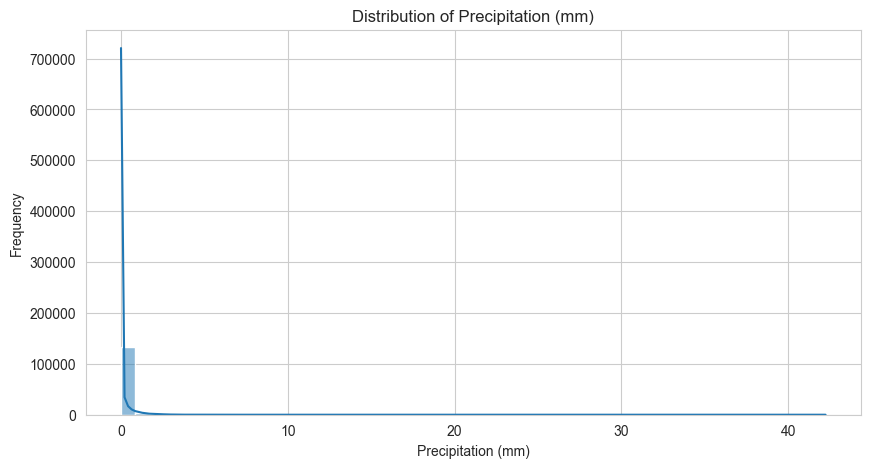

In [9]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["precip_mm"],
    bins=50,
    kde=True
)

plt.title("Distribution of Precipitation (mm)")
plt.xlabel("Precipitation (mm)")
plt.ylabel("Frequency")

plt.show()

### Observations

- The precipitation distribution is highly right-skewed.
- A large majority of observations are concentrated near 0 mm precipitation, indicating that non-rainy or low-rainfall conditions are the most common.
- Heavy rainfall events occur much less frequently but extend far into the upper tail of the distribution.
- The long right tail reflects the presence of extreme precipitation events such as storms and heavy rainfall conditions.
- This distribution is typical for weather datasets, where rainfall events are relatively infrequent compared to dry conditions.

## Air Quality Analysis (PM2.5)

PM2.5 particles are among the most important indicators of air pollution and environmental health risk. This analysis examines the distribution of PM2.5 concentrations across global locations.

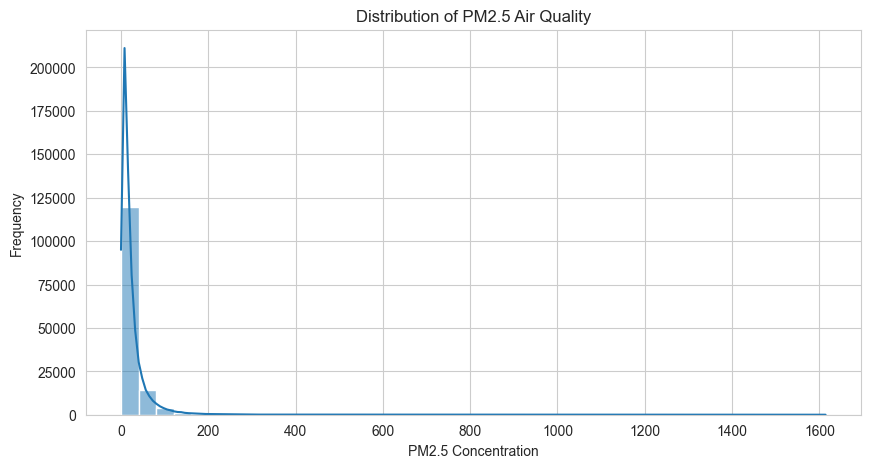

In [10]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["air_quality_pm2.5"],
    bins=40,
    kde=True
)

plt.title("Distribution of PM2.5 Air Quality")
plt.xlabel("PM2.5 Concentration")
plt.ylabel("Frequency")

plt.show()

### Observations

- The PM2.5 air quality distribution is highly right-skewed.
- Most observations are concentrated at relatively low PM2.5 levels, indicating generally moderate air quality conditions across many locations.
- A small number of observations extend to extremely high PM2.5 concentrations, creating a long upper tail in the distribution.
- These extreme values may correspond to severe pollution events, industrial regions, wildfire conditions, or dense urban environments.
- The distribution demonstrates substantial variability in global air quality conditions.
- The presence of extreme pollution spikes makes PM2.5 an important feature for anomaly and environmental impact analysis.

# Correlation and Multivariate Analysis

Multivariate analysis helps identify relationships between weather and environmental variables.

This section explores:
- Correlations between numerical features
- Relationships between temperature, humidity, precipitation, and air quality
- Patterns that may influence forecasting performance

Understanding these interactions is important for both environmental interpretation and predictive modeling.

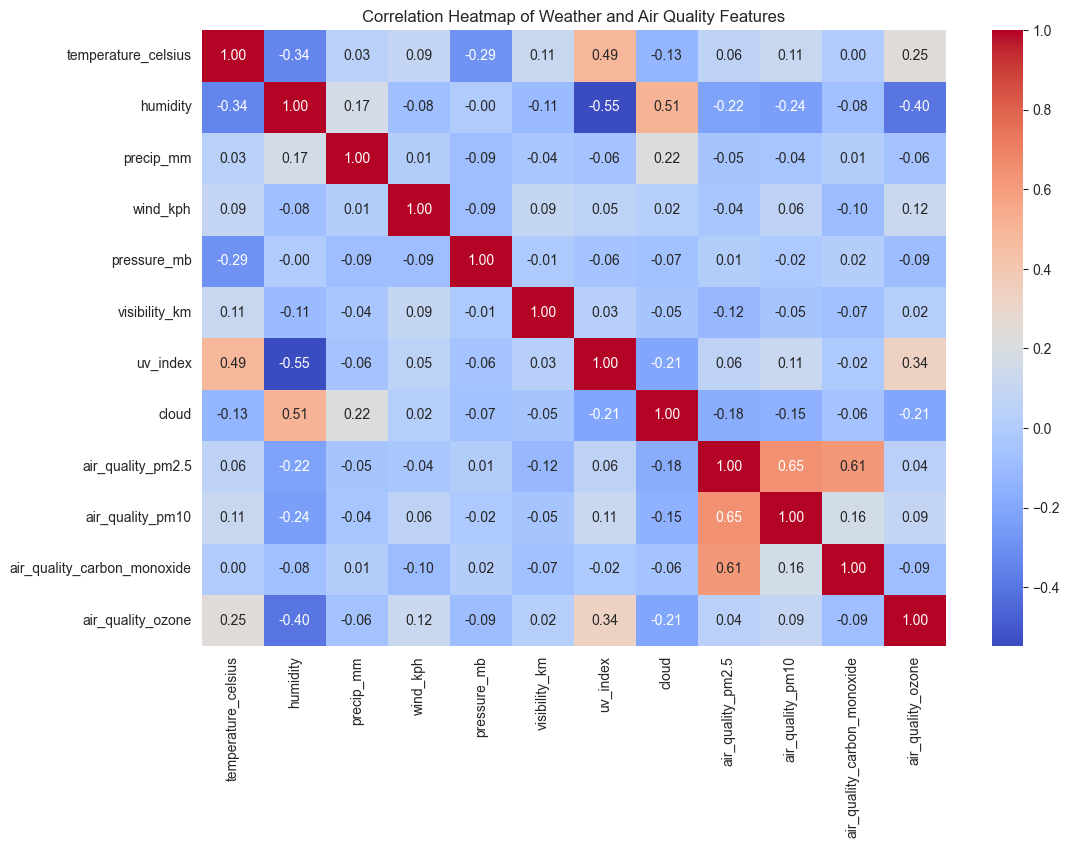

In [11]:
corr_features = [
    "temperature_celsius",
    "humidity",
    "precip_mm",
    "wind_kph",
    "pressure_mb",
    "visibility_km",
    "uv_index",
    "cloud",
    "air_quality_pm2.5",
    "air_quality_pm10",
    "air_quality_carbon_monoxide",
    "air_quality_ozone"
]

corr_matrix = df[corr_features].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Weather and Air Quality Features")
plt.savefig("../visuals/correlation_heatmap.png", bbox_inches="tight")
plt.show()

### Correlation Analysis Observations

- Temperature shows a moderate positive correlation with UV index (0.49), indicating that higher temperatures are generally associated with stronger ultraviolet radiation levels.
- Humidity has a strong negative correlation with UV index (-0.55), suggesting that highly humid conditions are often associated with lower UV exposure due to cloud cover and atmospheric moisture.
- Cloud cover demonstrates a moderate positive correlation with humidity (0.51), which aligns with expected atmospheric behavior.
- PM2.5 and PM10 exhibit a strong positive correlation (0.65), indicating that fine and coarse particulate pollutants often increase together in polluted environments.
- Carbon monoxide also shows a strong positive relationship with PM2.5 (0.61), suggesting common pollution sources such as traffic, industrial emissions, and combustion processes.
- Ozone displays a moderate negative relationship with humidity (-0.40), which may reflect atmospheric interactions between moisture and ozone formation.
- Most precipitation relationships appear relatively weak, indicating that rainfall patterns may be influenced by more complex regional and temporal factors.
- Overall, the correlation analysis highlights meaningful interactions between weather conditions and environmental pollution indicators.

# Time-Based Weather Trend Analysis

Time-based analysis helps identify seasonal and temporal weather behavior across the dataset.

This section explores:
- Monthly temperature trends
- Monthly precipitation patterns
- Seasonal weather variations
- Temporal environmental behavior

Understanding these trends is important for climate analysis and forecasting applications.

## Monthly Average Temperature Trend

This analysis examines how average temperature changes across different months of the year.

In [12]:
monthly_temp = (
    df.groupby("month")["temperature_celsius"]
    .mean()
    .reset_index()
)

monthly_temp

,month,temperature_celsius
0,1,16.072073
1,2,16.713934
2,3,18.696641
3,4,20.710786
4,5,23.548629
5,6,25.704565
6,7,26.019444
7,8,25.747953
8,9,24.248834
9,10,21.602371


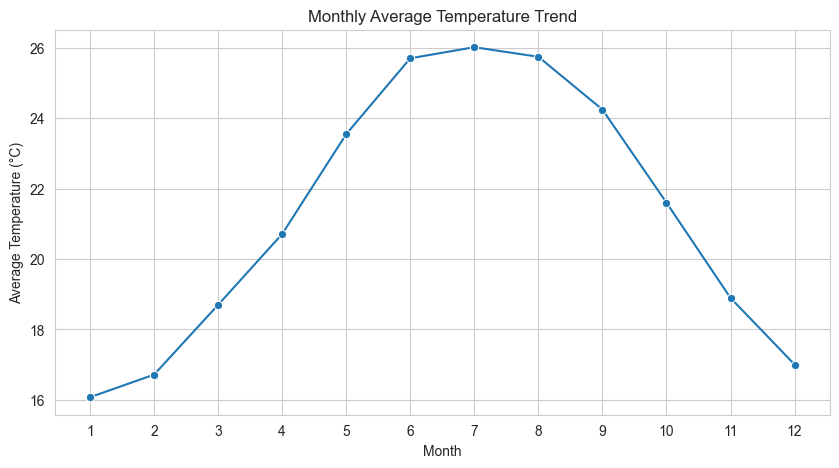

In [13]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=monthly_temp,
    x="month",
    y="temperature_celsius",
    marker="o"
)

plt.title("Monthly Average Temperature Trend")
plt.xlabel("Month")
plt.ylabel("Average Temperature (°C)")

plt.xticks(range(1, 13))

plt.show()

### Observations

- Average temperature shows a clear seasonal pattern throughout the year.
- Temperatures gradually increase from January and peak during June–July.
- The warmest period occurs around mid-year, with average temperatures reaching approximately 26°C.
- After July, temperatures begin to decline steadily toward the end of the year.
- The coldest months appear to be January and December.
- The smooth seasonal trend indicates strong temporal consistency in global temperature behavior.
- This seasonal structure suggests that time-based features such as month and season are likely to be important for forecasting models.

## Monthly Precipitation Trend

This analysis examines how average precipitation levels vary across different months of the year.

In [14]:
monthly_precip = (
    df.groupby("month")["precip_mm"]
    .mean()
    .reset_index()
)

monthly_precip

,month,precip_mm
0,1,0.122429
1,2,0.105888
2,3,0.122223
3,4,0.114408
4,5,0.146010
5,6,0.139808
6,7,0.167213
7,8,0.153617
8,9,0.152977
9,10,0.128500


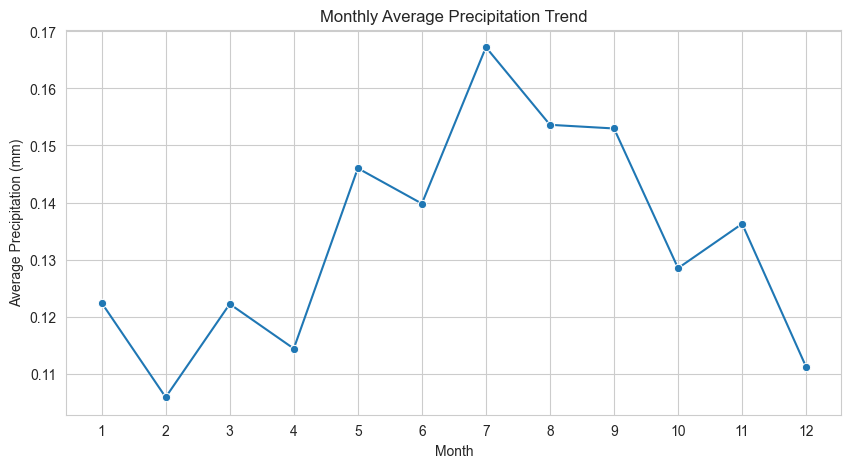

In [15]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=monthly_precip,
    x="month",
    y="precip_mm",
    marker="o"
)

plt.title("Monthly Average Precipitation Trend")
plt.xlabel("Month")
plt.ylabel("Average Precipitation (mm)")

plt.xticks(range(1, 13))

plt.show()

### Observations

- Monthly precipitation levels exhibit noticeable seasonal variation throughout the year.
- Average precipitation generally increases during the middle months of the year and reaches its highest level around July.
- After the peak, precipitation gradually decreases toward the later months.
- Compared to temperature trends, precipitation patterns appear more irregular and variable.
- The variability in precipitation suggests that rainfall behavior is influenced by complex regional and atmospheric factors.
- The observed mid-year precipitation peak may reflect seasonal rainfall and monsoon-related climatic effects in several regions represented within the dataset.

# Seasonal Climate Analysis

Seasonal analysis helps identify how weather conditions vary across different times of the year.

This section examines:
- Seasonal temperature behavior
- Seasonal precipitation patterns
- Climatic variations across seasons

Understanding seasonal behavior is important for climate trend analysis and weather forecasting.

## Seasonal Temperature Variation

This analysis compares average temperature levels across different seasons.

In [16]:
seasonal_temp = (
    df.groupby("season")["temperature_celsius"]
    .mean()
    .reset_index()
)

season_order = ["Winter", "Spring", "Summer", "Autumn"]

seasonal_temp["season"] = pd.Categorical(
    seasonal_temp["season"],
    categories=season_order,
    ordered=True
)

seasonal_temp = seasonal_temp.sort_values("season")

seasonal_temp

,season,temperature_celsius
3,Winter,16.595733
1,Spring,20.895912
2,Summer,25.822884
0,Autumn,21.584803


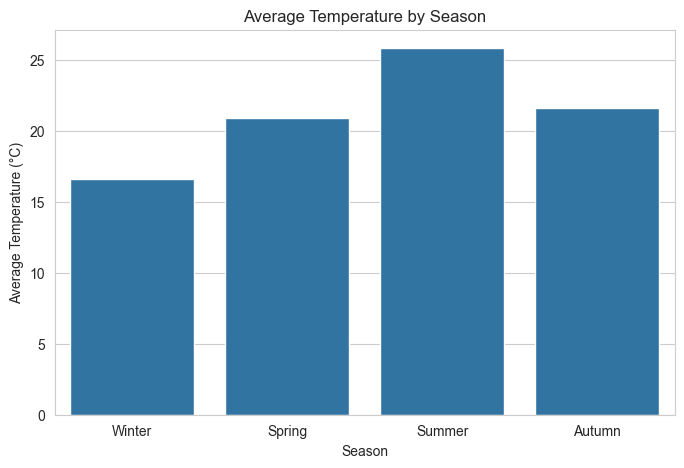

In [17]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=seasonal_temp,
    x="season",
    y="temperature_celsius"
)

plt.title("Average Temperature by Season")
plt.xlabel("Season")
plt.ylabel("Average Temperature (°C)")

plt.show()

### Observations

- Average temperature varies noticeably across seasons.
- Summer records the highest average temperature among all seasons.
- Winter shows the lowest average temperature levels.
- Spring and Autumn exhibit moderate temperature conditions between the seasonal extremes.
- The results demonstrate a clear and consistent seasonal climate cycle within the dataset.
- Seasonal temperature variation confirms the importance of temporal and seasonal features for climate analysis and forecasting tasks.

## Seasonal Precipitation Variation

This analysis compares precipitation levels across different seasons to identify seasonal rainfall behavior.

In [18]:
seasonal_precip = (
    df.groupby("season")["precip_mm"]
    .mean()
    .reset_index()
)

seasonal_precip["season"] = pd.Categorical(
    seasonal_precip["season"],
    categories=season_order,
    ordered=True
)

seasonal_precip = seasonal_precip.sort_values("season")

seasonal_precip

,season,precip_mm
3,Winter,0.113345
1,Spring,0.126970
2,Summer,0.153535
0,Autumn,0.139144


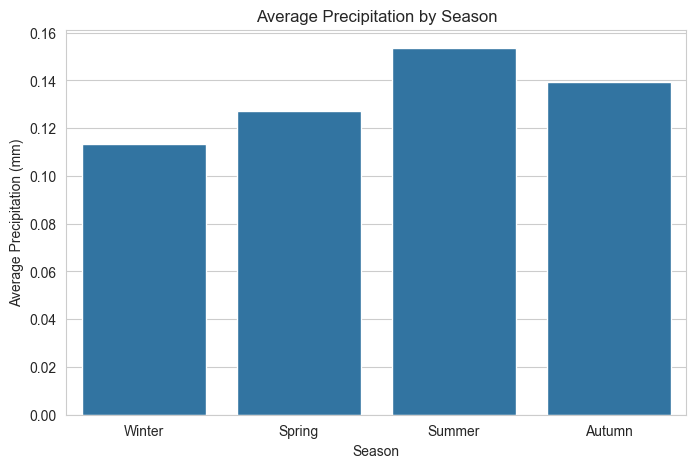

In [19]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=seasonal_precip,
    x="season",
    y="precip_mm"
)

plt.title("Average Precipitation by Season")
plt.xlabel("Season")
plt.ylabel("Average Precipitation (mm)")

plt.show()

### Observations

- Seasonal precipitation levels show clear variation throughout the year.
- Summer records the highest average precipitation among all seasons.
- Winter experiences the lowest average precipitation levels.
- Autumn and Spring show moderate precipitation conditions between the seasonal extremes.
- The higher precipitation levels during Summer may reflect seasonal rainfall and monsoon-related climatic behavior across several regions in the dataset.
- The observed seasonal precipitation trends highlight the strong relationship between climate seasonality and rainfall patterns.

# Geographical and Spatial Weather Analysis

Geographical analysis helps identify how weather conditions vary across different countries and regions around the world.

This section explores:
- Temperature variation across locations
- Regional climate differences
- Air quality patterns across geographical regions
- Spatial weather distributions

Understanding geographical weather behavior is important for climate monitoring and environmental analysis.

## Top 10 Hottest Countries

This analysis identifies countries with the highest average temperatures in the dataset.

In [20]:
country_temp = (
    df.groupby("country")["temperature_celsius"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

country_temp

,country,temperature_celsius
0,Saudi Arabien,45.000000
1,Marrocos,40.300000
2,Turkménistan,37.800000
3,Турция,34.000000
4,United Arab Emirates,32.093602
5,Qatar,32.060669
6,Cambodia,31.786072
7,Oman,31.465925
8,Djibouti,31.296513
9,Inde,31.200000


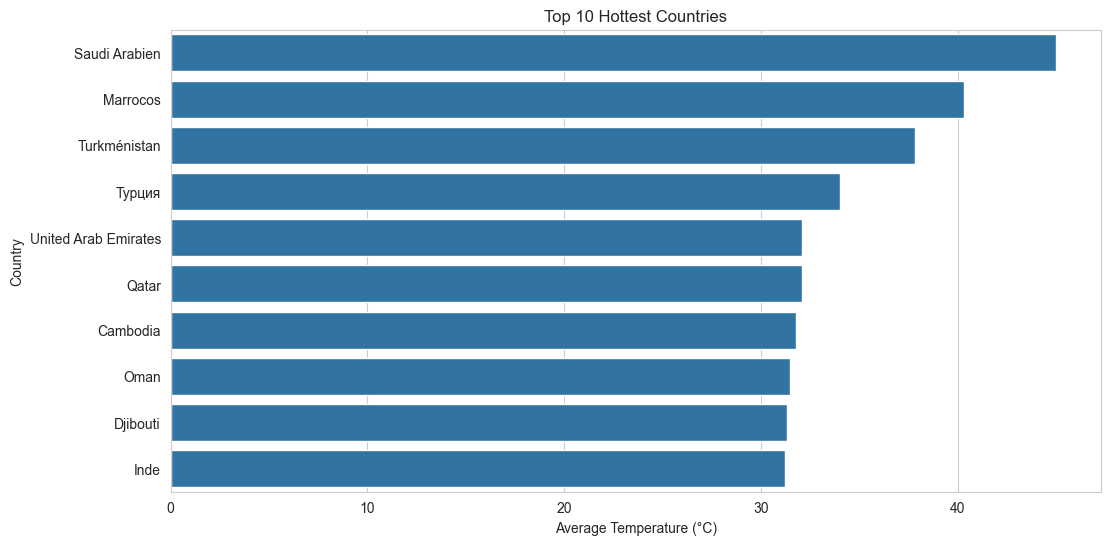

In [21]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=country_temp,
    x="temperature_celsius",
    y="country"
)

plt.title("Top 10 Hottest Countries")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Country")

plt.show()

### Observations

- Saudi Arabia records the highest average temperature among the countries analyzed.
- Several Middle Eastern and North African countries appear among the hottest regions in the dataset.
- Countries such as Saudi Arabia, Qatar, Oman, and the United Arab Emirates demonstrate consistently high temperature conditions.
- The results reflect the influence of arid and desert climates in these geographical regions.
- India and Cambodia also appear among the warmest countries, indicating strong tropical and subtropical climatic conditions.
- The analysis highlights clear geographical differences in global temperature distribution.

## Countries with the Highest PM2.5 Levels

This analysis identifies countries with the highest average PM2.5 concentrations, helping evaluate global air pollution patterns and environmental health conditions.

In [22]:
worst_pm25 = (
    df.groupby("country")["air_quality_pm2.5"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

worst_pm25

,country,air_quality_pm2.5
0,Chile,147.141557
1,Saudi Arabia,136.662521
2,China,131.304372
3,India,110.516367
4,Kuwait,91.476435
5,Indonesia,84.074322
6,Bangladesh,70.385258
7,Südkorea,70.200000
8,Mauritania,66.231936
9,Bahrain,64.306766


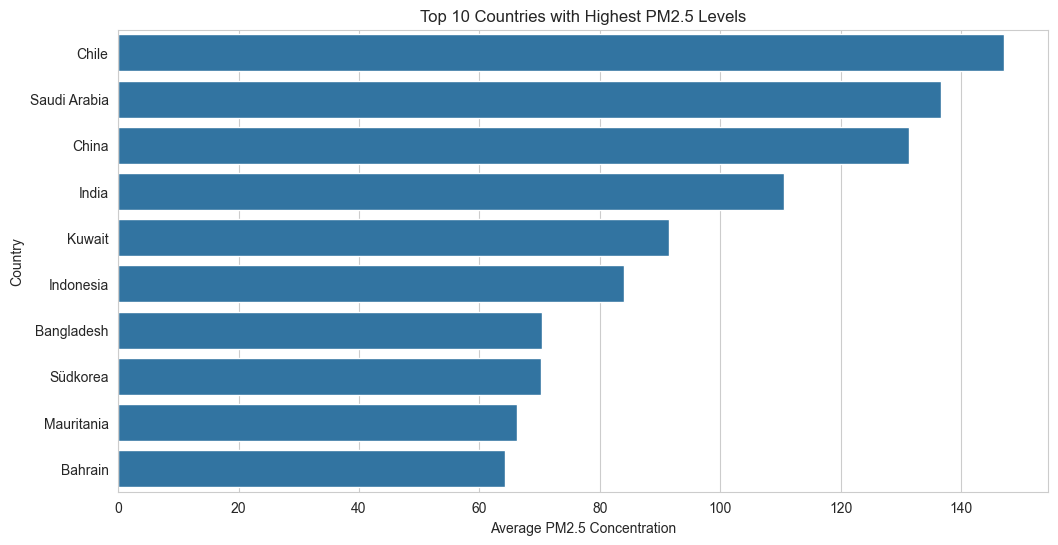

In [23]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=worst_pm25,
    x="air_quality_pm2.5",
    y="country"
)

plt.title("Top 10 Countries with Highest PM2.5 Levels")
plt.xlabel("Average PM2.5 Concentration")
plt.ylabel("Country")

plt.show()

### Observations

- Chile records the highest average PM2.5 concentration among the analyzed countries.
- Several Asian and Middle Eastern countries also exhibit high PM2.5 levels, including China, India, Saudi Arabia, Kuwait, and Bangladesh.
- Elevated PM2.5 concentrations may be associated with industrial activity, urbanization, traffic emissions, and environmental conditions.
- The analysis highlights substantial geographical variation in air pollution levels across different regions.
- High PM2.5 concentrations are environmentally significant because prolonged exposure can negatively affect air quality and public health.
- The results demonstrate the importance of integrating environmental indicators into weather and climate analysis.

## Relationship Between Temperature and Humidity

This analysis explores how humidity changes with temperature across global weather observations.

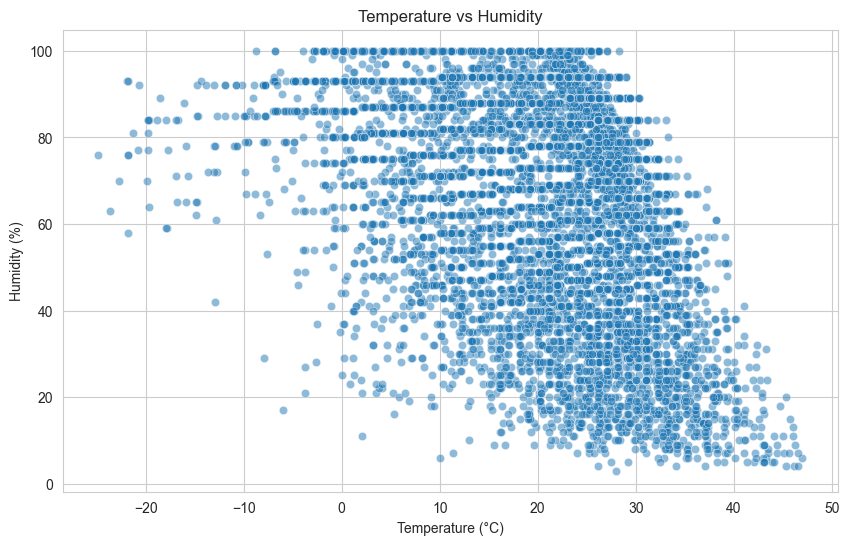

In [24]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df.sample(10000, random_state=42),
    x="temperature_celsius",
    y="humidity",
    alpha=0.5
)

plt.title("Temperature vs Humidity")
plt.xlabel("Temperature (°C)")
plt.ylabel("Humidity (%)")

plt.show()

### Observations

- Temperature and humidity exhibit a moderate negative relationship overall.
- Higher temperature conditions are generally associated with lower humidity levels.
- Extremely humid conditions are more concentrated within lower-to-moderate temperature ranges.
- The distribution shows substantial variability, indicating that humidity is influenced by multiple atmospheric and geographical factors.
- Several clusters of observations are visible, suggesting the presence of different climatic zones and environmental conditions across regions.
- The relationship between temperature and humidity is important for understanding perceived temperature, rainfall behavior, and weather forecasting dynamics.

# Spatial Weather Analysis

Spatial analysis helps visualize how weather conditions vary geographically across the world.

This section explores:
- Global temperature distribution
- Geographical weather variations
- Regional environmental patterns

Spatial visualization provides a clearer understanding of worldwide climatic behavior.

## Global Temperature Distribution Map

This map visualizes temperature observations across different geographical locations worldwide.

In [26]:
sample_df = df.sample(5000, random_state=42)

fig = px.scatter_geo(
    sample_df,
    lat="latitude",
    lon="longitude",
    color="temperature_celsius",
    hover_name="country",
    hover_data={
        "location_name": True,
        "temperature_celsius": True,
        "humidity": True
    },
    title="Global Temperature Distribution",
    color_continuous_scale="Turbo"
)

fig.show()
plt.savefig("../visuals/global_temperature_map.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

### Observations

- Warmer temperature regions are primarily concentrated around the Middle East, South Asia, and parts of Africa.
- Cooler temperature observations appear more frequently in higher-latitude regions such as Northern Europe and North America.
- Tropical and subtropical regions generally display moderate-to-high temperature conditions.
- The spatial distribution highlights strong geographical variation in global climate behavior.
- Temperature patterns appear closely influenced by latitude and regional climatic conditions.
- The visualization demonstrates how spatial analysis can help identify regional weather characteristics more effectively than numerical summaries alone.

## Global PM2.5 Air Quality Distribution

This map visualizes PM2.5 air pollution concentrations across global locations.

In [27]:
sample_df = df.sample(5000, random_state=42)

fig = px.scatter_geo(
    sample_df,
    lat="latitude",
    lon="longitude",
    color="air_quality_pm2.5",
    hover_name="country",
    hover_data={
        "location_name": True,
        "air_quality_pm2.5": True,
        "temperature_celsius": True
    },
    title="Global PM2.5 Air Quality Distribution",
    color_continuous_scale="Reds"
)

fig.show()

## Global Precipitation Distribution

This map visualizes precipitation intensity across different geographical regions.

In [28]:
sample_df = df.sample(5000, random_state=42)

fig = px.scatter_geo(
    sample_df,
    lat="latitude",
    lon="longitude",
    color="precip_mm",
    hover_name="country",
    hover_data={
        "location_name": True,
        "precip_mm": True,
        "humidity": True
    },
    title="Global Precipitation Distribution",
    color_continuous_scale="Blues"
)

fig.show()

# Anomaly Detection and Environmental Outlier Analysis

Anomaly detection helps identify unusual or extreme weather and environmental observations within the dataset.

In weather datasets, anomalies may correspond to:
- Extreme temperature events
- Heavy precipitation
- Severe pollution conditions
- Unusual atmospheric behavior

This section applies machine learning-based anomaly detection to identify potentially abnormal environmental observations.

In [29]:
anomaly_features = [
    "temperature_celsius",
    "humidity",
    "precip_mm",
    "wind_kph",
    "pressure_mb",
    "visibility_km",
    "air_quality_pm2.5",
    "air_quality_pm10"
]

anomaly_data = df[anomaly_features]

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(anomaly_data)

In [30]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.02,
    random_state=42
)

df["anomaly"] = iso_forest.fit_predict(scaled_data)

In [31]:
df["anomaly_label"] = df["anomaly"].map({
    1: "Normal",
    -1: "Anomaly"
})

df["anomaly_label"].value_counts()

anomaly_label
Normal     137149
Anomaly      2799
Name: count, dtype: int64

## Environmental Anomaly Visualization

This visualization highlights unusual environmental observations detected using the Isolation Forest algorithm.

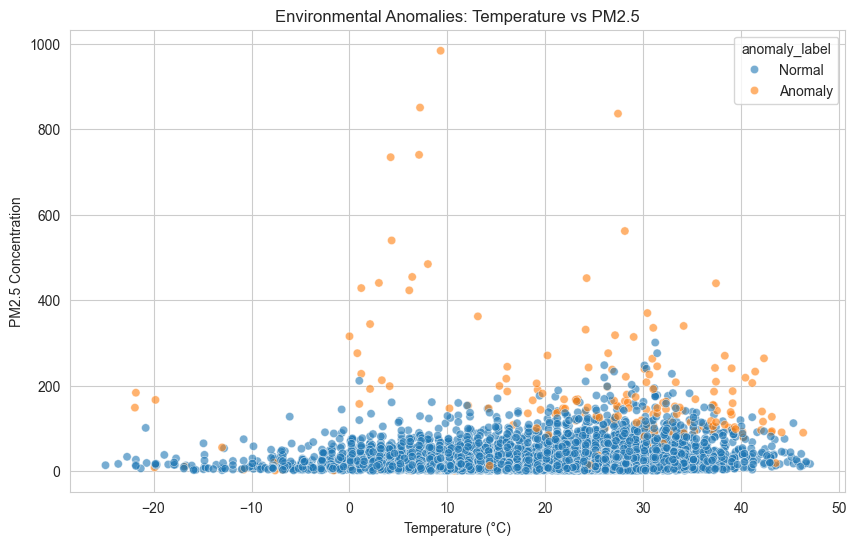

<Figure size 640x480 with 0 Axes>

In [32]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df.sample(10000, random_state=42),
    x="temperature_celsius",
    y="air_quality_pm2.5",
    hue="anomaly_label",
    alpha=0.6
)

plt.title("Environmental Anomalies: Temperature vs PM2.5")
plt.xlabel("Temperature (°C)")
plt.ylabel("PM2.5 Concentration")

plt.show()
plt.savefig("../visuals/anomaly_detection.png", bbox_inches="tight")

### Observations

- The Isolation Forest algorithm successfully identified unusual environmental observations within the dataset.
- Most detected anomalies are associated with extremely high PM2.5 concentrations, indicating severe pollution events or abnormal environmental conditions.
- Several anomalous observations occur within moderate-to-high temperature ranges, suggesting potential interactions between temperature and pollution intensity.
- The majority of normal observations remain concentrated within lower PM2.5 ranges, while anomalies are more dispersed and extreme.
- A few anomalies also appear at unusually low temperatures, highlighting the diversity of extreme weather and environmental conditions captured in the dataset.
- The anomaly detection results demonstrate the usefulness of machine learning techniques for identifying rare and environmentally significant events in large-scale weather datasets.

# Feature Importance Analysis

Feature importance analysis helps identify which environmental and weather variables contribute most strongly to temperature prediction.

Understanding feature influence is useful for:
- Interpreting weather behavior
- Improving forecasting models
- Identifying key climatic drivers

This section applies an XGBoost regression model to evaluate feature importance.`

In [33]:
feature_cols = [
    "humidity",
    "wind_kph",
    "pressure_mb",
    "precip_mm",
    "visibility_km",
    "uv_index",
    "cloud",
    "air_quality_pm2.5",
    "air_quality_pm10",
    "air_quality_ozone"
]

X = df[feature_cols]

y = df["temperature_celsius"]

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [35]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [36]:
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": xgb_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

importance_df

,feature,importance
5,uv_index,0.316195
2,pressure_mb,0.298168
0,humidity,0.088597
4,visibility_km,0.057896
6,cloud,0.053179
8,air_quality_pm10,0.045764
9,air_quality_ozone,0.045297
7,air_quality_pm2.5,0.037975
3,precip_mm,0.033574
1,wind_kph,0.023355


## XGBoost Feature Importance

This visualization shows the relative importance of different environmental variables in predicting temperature.

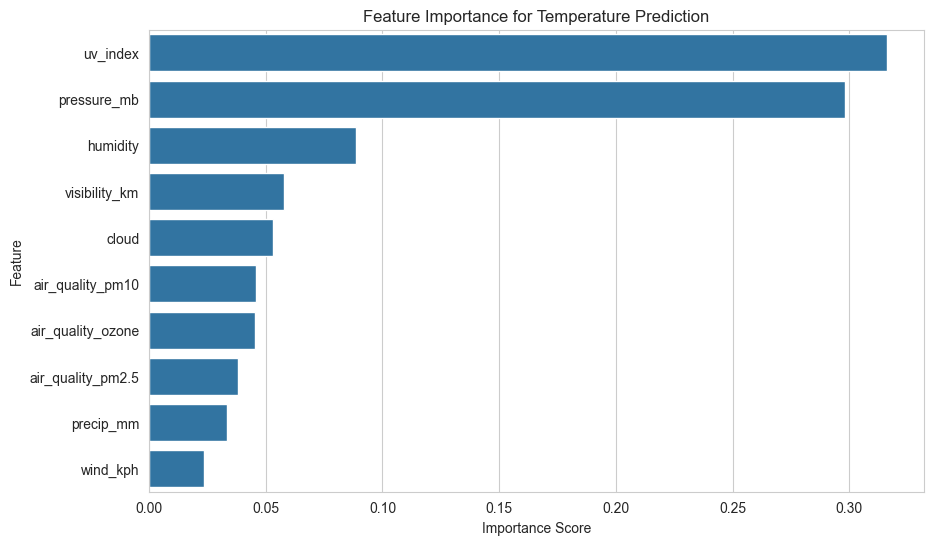

<Figure size 640x480 with 0 Axes>

In [38]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance_df,
    x="importance",
    y="feature"
)

plt.title("Feature Importance for Temperature Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()
plt.savefig("../visuals/feature_importance.png", bbox_inches="tight")

### Observations

- UV index emerged as the most important feature for temperature prediction.
- Atmospheric pressure also showed a strong influence on temperature behavior.
- Humidity demonstrated moderate predictive importance, indicating its relationship with atmospheric and thermal conditions.
- Visibility and cloud cover contributed meaningfully to temperature prediction, reflecting the impact of weather conditions on solar exposure and atmospheric behavior.
- Air quality indicators such as PM2.5, PM10, and ozone also contributed to the model, suggesting interactions between environmental pollution and climatic conditions.
- Wind speed and precipitation showed comparatively lower importance within this specific prediction task.
- Overall, the feature importance analysis highlights that both meteorological and environmental variables influence temperature behavior.